Libraries and functions

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,  Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit

Data import and DataFrame generation

In [230]:
path = Path() / "Dataset3_PortfolioReplicaStrategy.xlsx"

data = pd.read_excel(path)
data = data.set_index('Ticker')
data = data.sort_index()

data.head()

,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Ticker,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


Data preparation

In [231]:
index_components = {"MXWO" : 0.25,
                    "MXWD" : 0,
                    "LEGATRUU" : 0.25,
                    "HFRXGL" : 0.5}

component_returns = data[list(index_components.keys())].pct_change().dropna()

Y = sum(component_returns[col] * w for col, w in index_components.items())
Y.name = 'Monster_Index'

futures = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

X = data[futures].pct_change().dropna() # Futures matrix

common_dates = X.index.intersection(Y.index) # Riallineo i dataset
X = X.loc[common_dates]
Y = Y.loc[common_dates]

Train-Test split and futures returnstest standardization

Scaling di Y necessario per ottenere un termine di penalizzazione corretto per Ridge, Lasso ed Elastic Net


In [232]:
split_date = '2018-12-31'

X_train = X.loc[:split_date]
X_test = X.loc[split_date:]
Y_train = Y.loc[:split_date]
Y_test = Y.loc[split_date:]

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_Y = StandardScaler()

Y_train_scaled = pd.Series(
    scaler_Y.fit_transform(Y_train.values.reshape(-1, 1)).flatten(),
    index=Y_train.index
)

Y_test_scaled = pd.Series(
    scaler_Y.transform(Y_test.values.reshape(-1, 1)).flatten(),
    index=Y_test.index
)


Correlation analysis

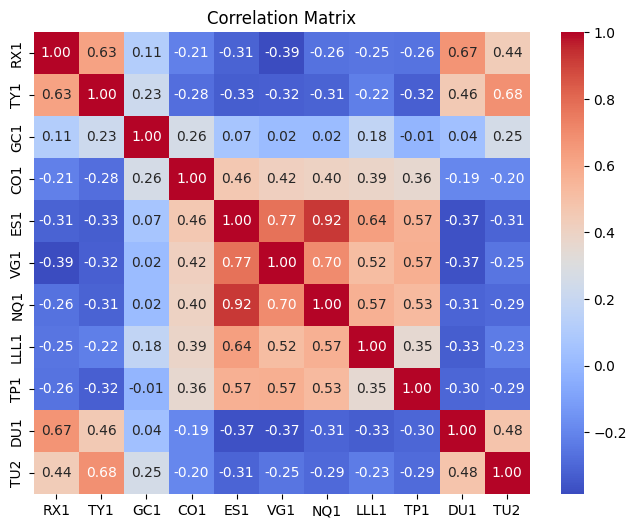

In [233]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

corr_matrix = X_train_scaled_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

---------------------------

Metriche

In [234]:
def annual_return(returns):
    ann_ret = returns.mean() * 52
    return ann_ret

def volatility(returns):
    vol = np.std(returns, ddof=1) * np.sqrt(52)
    return vol

def tracking_error_volatility(returns_replica, returns_target):
    tev = np.std(returns_replica - returns_target, ddof=1) * np.sqrt(52)
    return tev

def sharpe_ratio(returns):
    sharpe = annual_return(returns) / volatility(returns)
    return sharpe

def max_drawdown(returns):
    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

def gross_exposure(weights_history):
    weights_df = pd.DataFrame(weights_history)
    return weights_df.abs().sum(axis=1).mean()

def correlation(returns_replica, returns_target):
    corr = returns_replica.corr(returns_target)
    return corr

def information_ratio(returns_replica, returns_target):
    active_returns = returns_replica - returns_target
    
    excess_return = active_returns.mean() * 52
    tracking_error = active_returns.std(ddof=1) * np.sqrt(52)
    
    if tracking_error == 0:
        return np.nan
    
    return excess_return / tracking_error

def r2_oos(y_pred, y_true):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def compute_metrics(y_pred, y_true, weights):
    return [
        annual_return(y_pred) * 100,
        volatility(y_pred) * 100,
        sharpe_ratio(y_pred),
        max_drawdown(y_pred) * 100,
        tracking_error_volatility(y_pred, y_true) * 100,
        gross_exposure(weights),
        information_ratio(y_pred, y_true),
        correlation(y_pred, y_true),
        r2_oos(y_pred, y_true)
    ]

Sweep con time-series cross validation per Ridge, Lasso ed Elastic Net

In [235]:
# ---------- RIDGE ----------

alphas_ridge = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
tscv_ridge = TimeSeriesSplit(n_splits=3)

model_cv_ridge = RidgeCV(alphas=alphas_ridge, cv=tscv_ridge, fit_intercept=False)
model_cv_ridge.fit(X_train_scaled, Y_train_scaled)

best_alpha_ridge = model_cv_ridge.alpha_
print(f"Best alpha Ridge: {best_alpha_ridge}")

# ---------- LASSO ----------

alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
tscv_lasso = TimeSeriesSplit(n_splits=3)

model_cv_lasso = LassoCV(alphas=alphas_lasso, cv=tscv_lasso, fit_intercept=False)
model_cv_lasso.fit(X_train_scaled, Y_train_scaled)

best_alpha_lasso = model_cv_lasso.alpha_
print(f"Best alpha Lasso: {best_alpha_lasso}")

# ---------- ELASTIC NET ----------

alphas_elastic = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
tscv_elastic = TimeSeriesSplit(n_splits=3)

model_cv_elastic = ElasticNetCV(alphas=alphas_elastic, 
                                l1_ratio=l1_ratios, 
                                cv=tscv_elastic, 
                                fit_intercept=False)
model_cv_elastic.fit(X_train_scaled, Y_train_scaled)

best_alpha_elastic = model_cv_elastic.alpha_
best_l1_ratio = model_cv_elastic.l1_ratio_
print(f"Best alpha Elastic: {best_alpha_elastic}")
print(f"Best l1 ratio Elastic: {best_l1_ratio}")



Best alpha Ridge: 10.0
Best alpha Lasso: 0.05
Best alpha Elastic: 0.05
Best l1 ratio Elastic: 0.5


Run di modelli OLS, Ridge, Lasso ed Elastic Net

In [236]:
def run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'OLS',
    rolling_window    = 26,
    alpha             = 0.01,
    l1_ratio          = 0.5,
    transaction_costs = False,
    lambda_           = None
):
    # ── Setup ─────────────────────────────────────────────────────────────
    normalize_y  = model_type in ['Ridge', 'Lasso', 'ElasticNet']
    Y_tr         = Y_train_scaled if normalize_y else Y_train
    X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
    Y_all        = pd.concat([Y_train_scaled if normalize_y else Y_train,
                              Y_test_scaled  if normalize_y else Y_test])
    X_all        = pd.concat([X_train, X_test])
    n_train      = len(X_train_scaled)

    def get_model():
        if model_type == 'OLS':
            return LinearRegression(fit_intercept=False)
        elif model_type == 'Ridge':
            return Ridge(alpha=alpha, fit_intercept=False)
        elif model_type == 'Lasso':
            return Lasso(alpha=alpha, fit_intercept=False)
        elif model_type == 'ElasticNet':
            return ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=False)
        else:
            raise ValueError(f"model_type '{model_type}' non riconosciuto.")

    def get_exp_weights(size):
        if lambda_ is not None:
            return np.array([lambda_ ** (size - 1 - i) for i in range(size)])
        return None

    def rescale_weights(coef):
        if normalize_y:
            # Modelli penalizzati: rescala da spazio normalizzato a originale
            return coef * scaler_Y.scale_[0] / scaler_X.scale_
        else:
            # OLS: usa i coefficienti così come sono
            return coef

    # ── TRAIN LOOP ────────────────────────────────────────────────────────
    predicted_returns_train = []
    weights_train           = []
    dates_train             = []
    prev_weights            = np.zeros(X_train_scaled.shape[1])

    for i in range(len(X_train_scaled) - rolling_window - 1):
        X_window    = X_train_scaled[i : i + rolling_window]
        Y_window    = Y_tr.iloc[i : i + rolling_window]
        exp_weights = get_exp_weights(rolling_window)

        model = get_model()
        if exp_weights is not None:
            model.fit(X_window, Y_window, sample_weight=exp_weights)
        else:
            model.fit(X_window, Y_window)

        actual_weights  = rescale_weights(model.coef_)

        # OLS predice con X scalato, penalizzati con X originale
        if normalize_y:
            next_X_original = X_train.iloc[i + rolling_window].values
            pred_gross      = np.dot(next_X_original, actual_weights)
        else:
            next_X_scaled   = X_train_scaled[i + rolling_window].reshape(1, -1)
            pred_gross      = model.predict(next_X_scaled)[0]

        if transaction_costs:
            turnover     = np.sum(np.abs(actual_weights - prev_weights))
            pred_gross   = pred_gross - 0.0005 * turnover
            prev_weights = actual_weights

        predicted_returns_train.append(pred_gross)
        weights_train.append(actual_weights)
        dates_train.append(Y_train.index[i + rolling_window])

    # ── TEST LOOP ─────────────────────────────────────────────────────────
    predicted_returns_test = []
    weights_test           = []
    dates_test             = []
    prev_weights_test      = weights_train[-1].copy()

    for j in range(n_train, len(X_all_scaled)):
        X_window    = X_all_scaled[j - rolling_window : j]
        Y_window    = Y_all.iloc[j - rolling_window : j]
        exp_weights = get_exp_weights(rolling_window)

        model = get_model()
        if exp_weights is not None:
            model.fit(X_window, Y_window, sample_weight=exp_weights)
        else:
            model.fit(X_window, Y_window)

        actual_weights = rescale_weights(model.coef_)

        # OLS predice con X scalato, penalizzati con X originale
        if normalize_y:
            next_X_original = X_all.iloc[j].values
            pred_gross      = np.dot(next_X_original, actual_weights)
        else:
            next_X_scaled   = X_all_scaled[j].reshape(1, -1)
            pred_gross      = model.predict(next_X_scaled)[0]

        if transaction_costs:
            turnover          = np.sum(np.abs(actual_weights - prev_weights_test))
            pred_gross        = pred_gross - 0.0005 * turnover
            prev_weights_test = actual_weights

        predicted_returns_test.append(pred_gross)
        weights_test.append(actual_weights)
        dates_test.append(Y_all.index[j])

    Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
    Y_pred_test  = pd.Series(predicted_returns_test,  index=dates_test)

    return {
        'Y_pred_train' : Y_pred_train,
        'Y_pred_test'  : Y_pred_test,
        'weights_train': weights_train,
        'weights_test' : weights_test,
        'dates_train'  : dates_train,
        'dates_test'   : dates_test
    }

In [237]:
# ── OLS ───────────────────────────────────────────────────────────────────
res_ols = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'OLS',
    rolling_window    = 52,
    transaction_costs = True
)

# ── RIDGE ─────────────────────────────────────────────────────────────────
res_ridge = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'Ridge',
    rolling_window    = 52,
    alpha             = best_alpha_ridge,
    transaction_costs = True
)

# ── LASSO ─────────────────────────────────────────────────────────────────
res_lasso = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'Lasso',
    rolling_window    = 52,
    alpha             = best_alpha_lasso,
    transaction_costs = True
)

# ── ELASTIC NET ───────────────────────────────────────────────────────────
res_elastic = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'ElasticNet',
    rolling_window    = 52,
    alpha             = best_alpha_elastic,
    l1_ratio          = best_l1_ratio,
    transaction_costs = True
)

# ── ESTRAZIONE RISULTATI ──────────────────────────────────────────────────
Y_pred_test_ols     = res_ols['Y_pred_test']
Y_pred_test_ridge   = res_ridge['Y_pred_test']
Y_pred_test_lasso   = res_lasso['Y_pred_test']
Y_pred_test_elastic = res_elastic['Y_pred_test']

weights_test_ols     = res_ols['weights_test']
weights_test_ridge   = res_ridge['weights_test']
weights_test_lasso   = res_lasso['weights_test']
weights_test_elastic = res_elastic['weights_test']

In [238]:
# ── ALLINEAMENTO DATE ─────────────────────────────────────────────────────
Y_test_aligned         = Y_test.loc[Y_pred_test_ols.index]
Y_test_aligned_ridge   = Y_test.loc[Y_pred_test_ridge.index]
Y_test_aligned_lasso   = Y_test.loc[Y_pred_test_lasso.index]
Y_test_aligned_elastic = Y_test.loc[Y_pred_test_elastic.index]

# ── METRICHE ──────────────────────────────────────────────────────────────
metric_names = [
    'Annualized return',
    'Annualized volatility',
    'Sharpe ratio',
    'Max Drawdown',
    'Tracking Error Volatility',
    'Gross Exposure',
    'Information Ratio',
    'Correlation',
    'R2'
]

target_values = [
    annual_return(Y_test_aligned) * 100,
    volatility(Y_test_aligned) * 100,
    sharpe_ratio(Y_test_aligned),
    max_drawdown(Y_test_aligned) * 100,
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A'
]

metrics = pd.DataFrame({
    'Metric'             : metric_names,
    'Target'             : target_values,
    'Replica OLS'        : compute_metrics(Y_pred_test_ols,     Y_test_aligned,         weights_test_ols),
    'Replica Ridge'      : compute_metrics(Y_pred_test_ridge,   Y_test_aligned_ridge,   weights_test_ridge),
    'Replica Lasso'      : compute_metrics(Y_pred_test_lasso,   Y_test_aligned_lasso,   weights_test_lasso),
    'Replica Elastic Net': compute_metrics(Y_pred_test_elastic, Y_test_aligned_elastic, weights_test_elastic)
})

metrics

,Metric,Target,Replica OLS,Replica Ridge,Replica Lasso,Replica Elastic Net
0,Annualized return,11.074009,11.553893,9.415348,9.629811,9.686977
1,Annualized volatility,7.171301,6.131171,5.097346,5.405115,5.548085
2,Sharpe ratio,1.544212,1.884451,1.847108,1.781611,1.746004
3,Max Drawdown,-13.388949,-7.971113,-6.581721,-6.251465,-6.922436
4,Tracking Error Volatility,N/A,3.774501,4.590763,4.413042,4.357436
5,Gross Exposure,N/A,0.256453,1.536415,0.958348,1.261639
6,Information Ratio,N/A,0.127138,-0.361304,-0.327257,-0.318314
7,Correlation,N/A,0.850291,0.770565,0.789025,0.794500
8,R2,N/A,0.722885,0.589161,0.620527,0.630071


In [239]:
weights_df_ols = pd.DataFrame(
    weights_test_ols,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_df_ridge = pd.DataFrame(
    weights_test_ridge,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_df_lasso = pd.DataFrame(
    weights_test_lasso,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_df_elastic = pd.DataFrame(
    weights_test_elastic,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_summary = pd.DataFrame({
    'OLS':         weights_df_ols.abs().mean(),
    'Ridge':       weights_df_ridge.abs().mean(),
    'Lasso':       weights_df_lasso.abs().mean(),
    'Elastic Net': weights_df_elastic.abs().mean()
}).round(4)

weights_summary = weights_summary.sort_values('OLS', ascending=False)
weights_summary

,OLS,Ridge,Lasso,Elastic Net
LLL1,0.2351,0.0006,0.0000,0.0000
ES1,0.0073,0.1689,0.2634,0.2423
DU1,0.0024,0.8300,0.4849,0.7112
TP1,0.0023,0.0476,0.0314,0.0483
NQ1,0.0020,0.0431,0.0173,0.0350
TY1,0.0018,0.0522,0.0058,0.0189
VG1,0.0016,0.0466,0.0143,0.0269
TU2,0.0016,0.1792,0.0010,0.0301
GC1,0.0011,0.0360,0.0219,0.0356
RX1,0.0009,0.1262,0.1180,0.1122


In [240]:
weights_frequency = pd.DataFrame({
    'Lasso'       : (weights_df_lasso != 0).mean() * 100,
    'Elastic Net' : (weights_df_elastic != 0).mean() * 100
}).round(4)

weights_frequency = weights_frequency.sort_values('Lasso', ascending=False)
weights_frequency


,Lasso,Elastic Net
ES1,100.0000,100.0000
TP1,86.7769,98.3471
GC1,76.8595,96.6942
NQ1,76.0331,96.6942
VG1,48.7603,70.2479
RX1,47.1074,48.7603
DU1,42.9752,44.6281
TY1,15.7025,38.8430
CO1,13.2231,50.4132
TU2,0.8264,31.4050


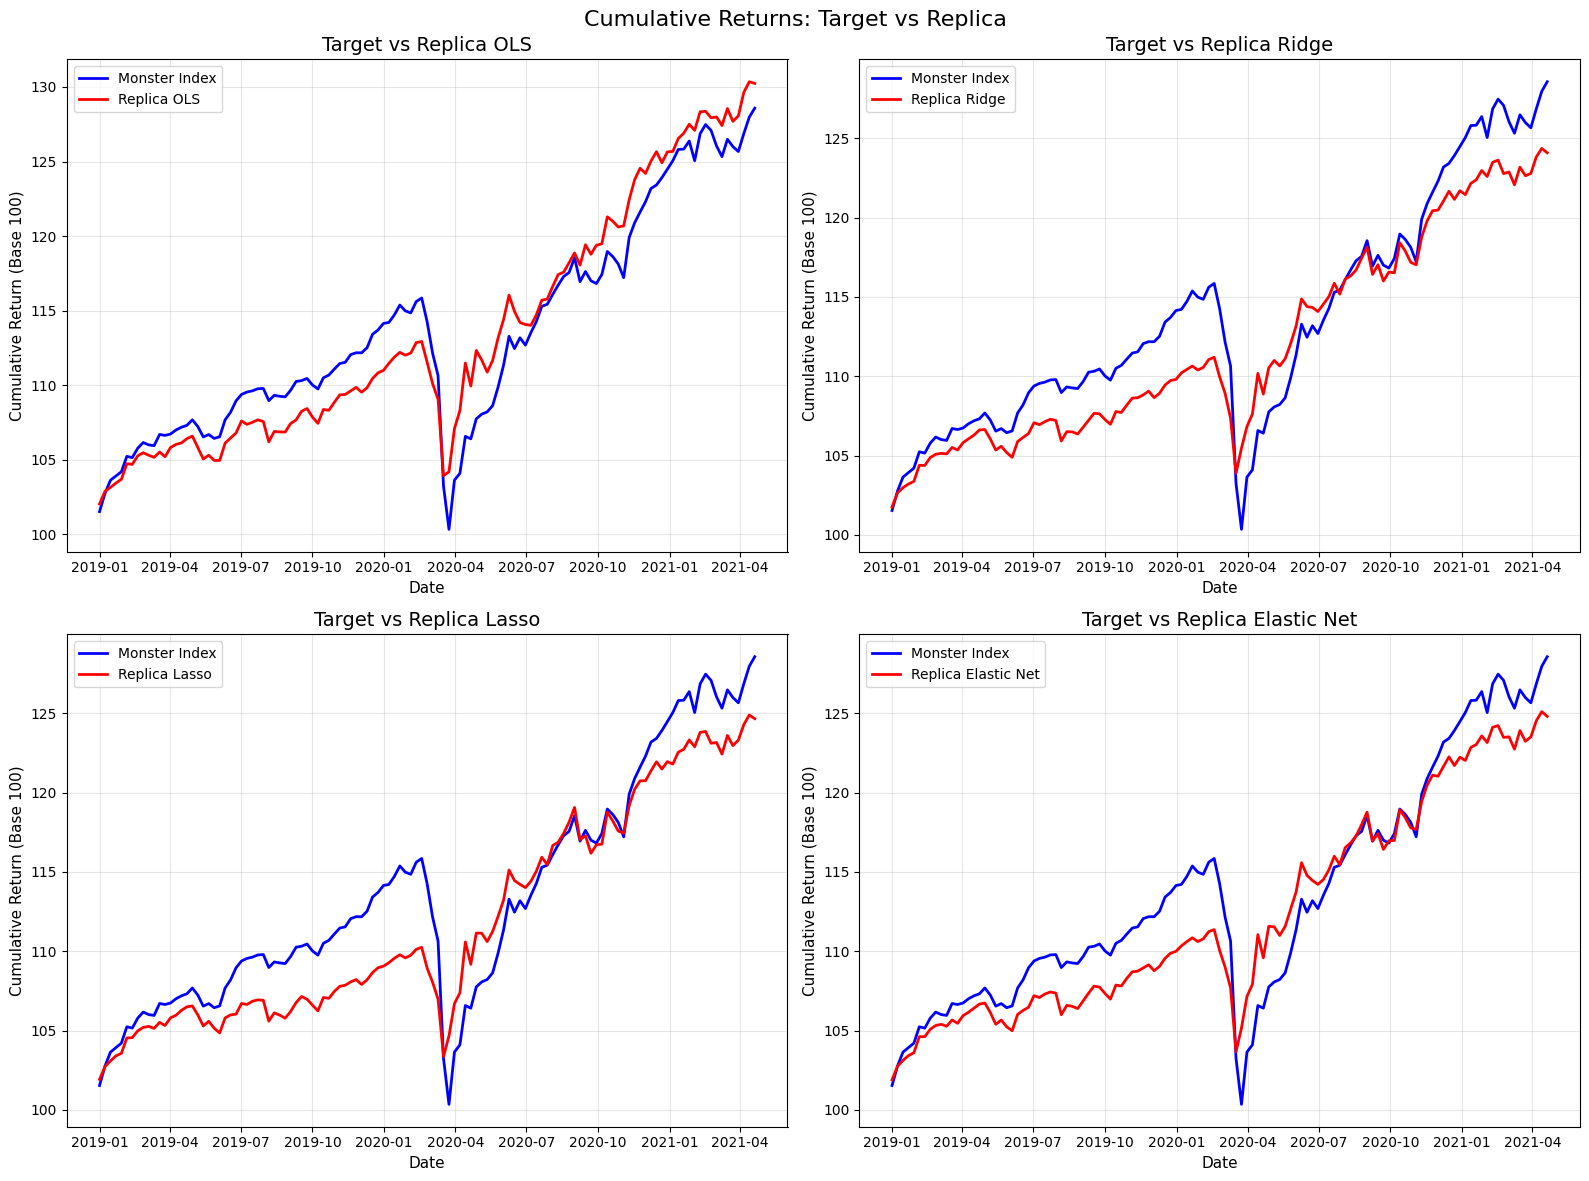

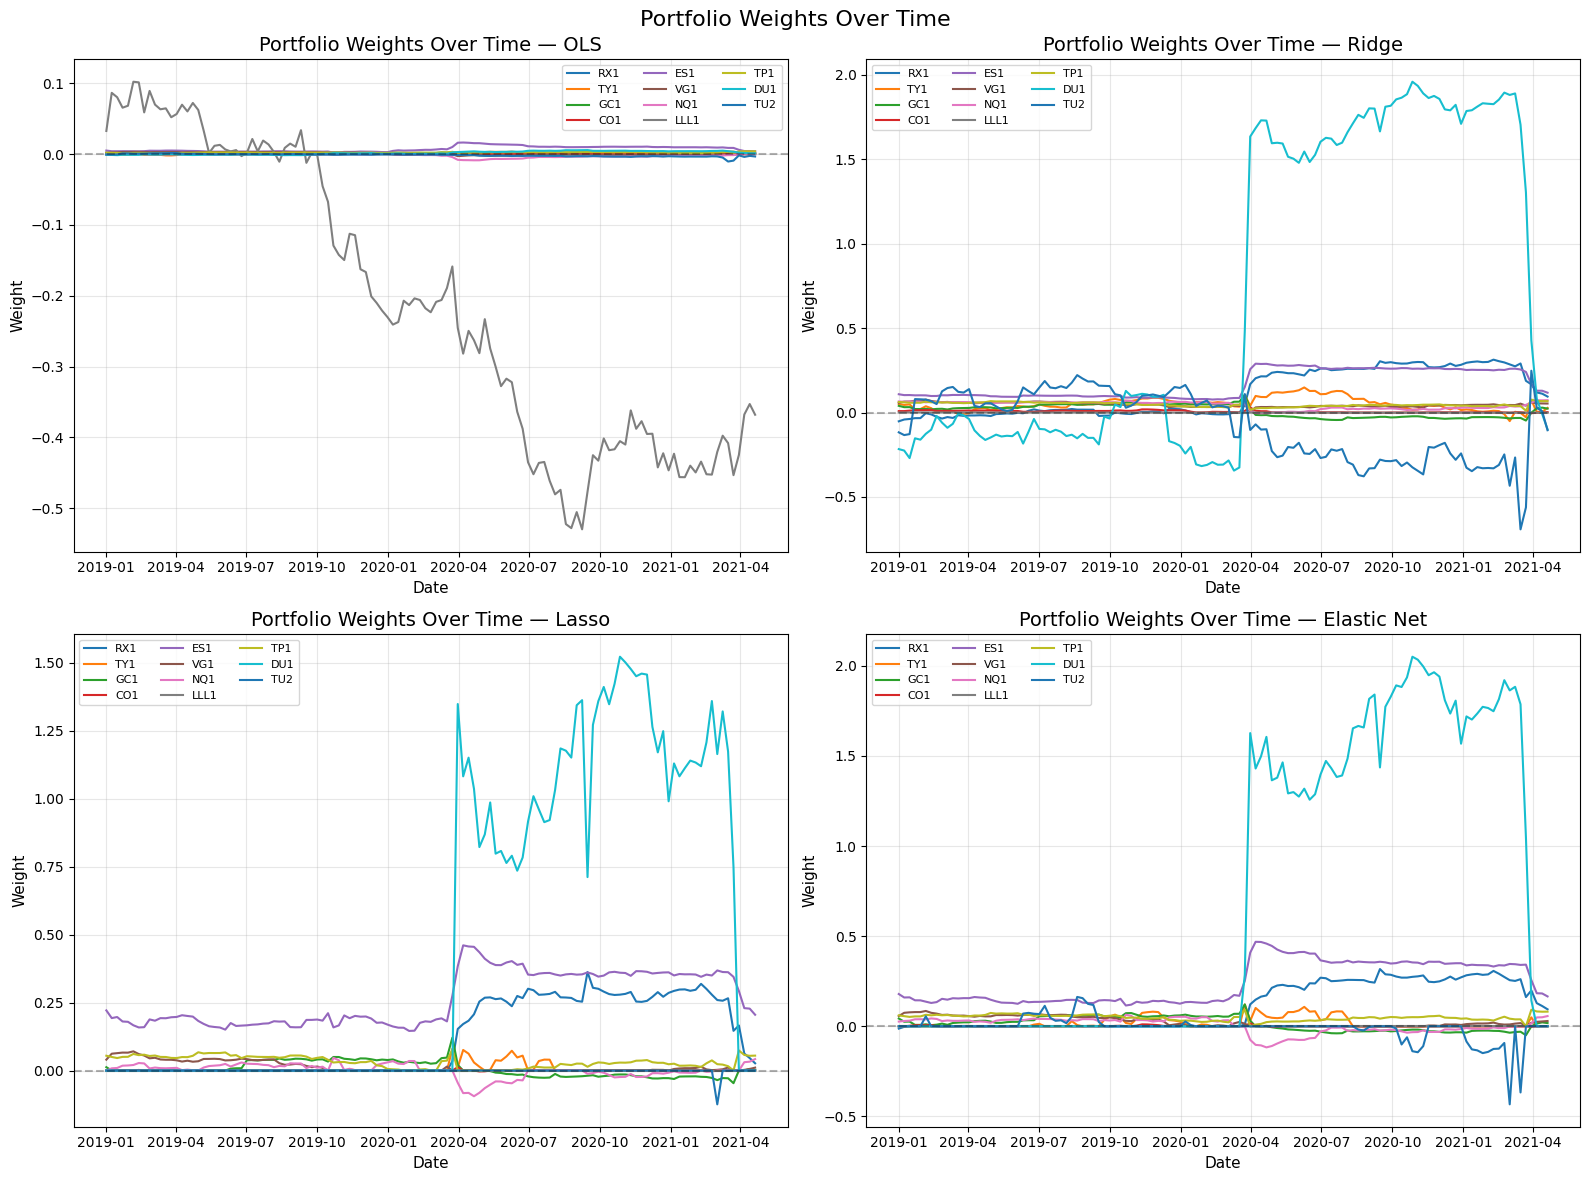

In [241]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models = {
    'OLS':         Y_pred_test_ols,
    'Ridge':       Y_pred_test_ridge,
    'Lasso':       Y_pred_test_lasso,
    'Elastic Net': Y_pred_test_elastic
}

for idx, (name, y_pred) in enumerate(models.items()):
    y_test_aligned     = Y_test.loc[y_pred.index]
    cumulative_target  = (1 + y_test_aligned).cumprod() * 100
    cumulative_replica = (1 + y_pred).cumprod() * 100
    
    axes[idx].plot(cumulative_target,  label='Monster Index', color='blue', linewidth=2)
    axes[idx].plot(cumulative_replica, label=f'Replica {name}', color='red', linewidth=2)
    axes[idx].set_title(f'Target vs Replica {name}', fontsize=14)
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('Cumulative Return (Base 100)', fontsize=11)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Cumulative Returns: Target vs Replica', fontsize=16)
plt.tight_layout()
plt.show()

# ── PLOT PESI NEL TEMPO ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_weights = {
    'OLS'        : (weights_test_ols,     res_ols['dates_test']),
    'Ridge'      : (weights_test_ridge,   res_ridge['dates_test']),
    'Lasso'      : (weights_test_lasso,   res_lasso['dates_test']),
    'Elastic Net': (weights_test_elastic, res_elastic['dates_test'])
}

for idx, (name, (weights, dates)) in enumerate(models_weights.items()):
    weights_df = pd.DataFrame(weights, index=dates, columns=X_train.columns)
    
    for col in weights_df.columns:
        axes[idx].plot(weights_df[col], label=col, linewidth=1.5)
    
    axes[idx].set_title(f'Portfolio Weights Over Time — {name}', fontsize=14)
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('Weight', fontsize=11)
    axes[idx].legend(fontsize=8, ncol=3)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.suptitle('Portfolio Weights Over Time', fontsize=16)
plt.tight_layout()
plt.show()

I modelli migliori risultano Lasso ed Elastic Net con rolling window di 52 settimane

In [247]:
# ── LASSO ─────────────────────────────────────────────────────────────────
res_lasso = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'Lasso',
    rolling_window    = 52,
    alpha             = best_alpha_lasso,
    transaction_costs = True
)

# ── ELASTIC NET ───────────────────────────────────────────────────────────
res_elastic = run_model(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    Y_train, Y_test,
    Y_train_scaled, Y_test_scaled,
    scaler_X, scaler_Y,
    model_type        = 'ElasticNet',
    rolling_window    = 156,
    alpha             = best_alpha_elastic,
    l1_ratio          = best_l1_ratio,
    transaction_costs = True
)

# ── ESTRAZIONE RISULTATI ──────────────────────────────────────────────────
Y_pred_test_lasso   = res_lasso['Y_pred_test']
Y_pred_test_elastic = res_elastic['Y_pred_test']

weights_test_lasso   = res_lasso['weights_test']
weights_test_elastic = res_elastic['weights_test']

# ── ALLINEAMENTO DATE ─────────────────────────────────────────────────────
Y_test_aligned_lasso   = Y_test.loc[Y_pred_test_lasso.index]
Y_test_aligned_elastic = Y_test.loc[Y_pred_test_elastic.index]

# ── METRICHE ──────────────────────────────────────────────────────────────
metric_names = [
    'Annualized return',
    'Annualized volatility',
    'Sharpe ratio',
    'Max Drawdown',
    'Tracking Error Volatility',
    'Gross Exposure',
    'Information Ratio',
    'Correlation',
    'R2'
]

target_values = [
    annual_return(Y_test_aligned) * 100,
    volatility(Y_test_aligned) * 100,
    sharpe_ratio(Y_test_aligned),
    max_drawdown(Y_test_aligned) * 100,
    'N/A', 'N/A', 'N/A', 'N/A', 'N/A'
]

metrics = pd.DataFrame({
    'Metric'             : metric_names,
    'Target'             : target_values,
    'Replica Lasso'      : compute_metrics(Y_pred_test_lasso,   Y_test_aligned_lasso,   weights_test_lasso),
    'Replica Elastic Net': compute_metrics(Y_pred_test_elastic, Y_test_aligned_elastic, weights_test_elastic)
})

metrics

,Metric,Target,Replica Lasso,Replica Elastic Net
0,Annualized return,11.074009,9.629811,9.475146
1,Annualized volatility,7.171301,5.405115,5.640422
2,Sharpe ratio,1.544212,1.781611,1.679865
3,Max Drawdown,-13.388949,-6.251465,-8.416653
4,Tracking Error Volatility,N/A,4.413042,4.107133
5,Gross Exposure,N/A,0.958348,0.627946
6,Information Ratio,N/A,-0.327257,-0.389289
7,Correlation,N/A,0.789025,0.820454
8,R2,N/A,0.620527,0.671030


In [243]:
weights_df_lasso = pd.DataFrame(
    weights_test_lasso,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_df_elastic = pd.DataFrame(
    weights_test_elastic,
    index=res_ols['dates_test'],
    columns=X_train.columns
)

weights_summary = pd.DataFrame({
    'Lasso':       weights_df_lasso.abs().mean(),
    'Elastic Net': weights_df_elastic.abs().mean()
}).round(4)

weights_summary = weights_summary.sort_values('Lasso', ascending=False)
weights_summary

,Lasso,Elastic Net
DU1,0.4849,0.7112
ES1,0.2634,0.2423
RX1,0.1180,0.1122
TP1,0.0314,0.0483
GC1,0.0219,0.0356
NQ1,0.0173,0.0350
VG1,0.0143,0.0269
TY1,0.0058,0.0189
TU2,0.0010,0.0301
CO1,0.0003,0.0011


## Risultati e Conclusioni — Modelli Statistici

### Approccio Metodologico
I modelli sono stati implementati con una rolling window di 52 settimane,
selezionata tramite cross-validation temporale (TimeSeriesSplit, n_splits=2)
minimizzando il Tracking Error sul train set. La normalizzazione è applicata
solo a X (StandardScaler), mentre Y rimane in scala originale per OLS e viene
normalizzata per i modelli penalizzati con rescaling dei pesi allo spazio
originale. La selezione degli iperparametri (α, l1_ratio) è stata effettuata
tramite ElasticNetCV e LassoCV con TimeSeriesSplit sul train set.

### Feature Selection
La correlation matrix dei futures ha evidenziato alta collinearità tra ES1 e NQ1
(0.92) e tra futures azionari in generale. Invece di rimuovere manualmente i
futures correlati, si è scelto di affidarsi alla penalizzazione L1 di Lasso ed
Elastic Net per la selezione automatica — più robusta e adattiva nel tempo.

### Modelli Candidati

I due modelli candidati finali sono **Lasso** ed **Elastic Net**, entrambi con
rolling window di 52 settimane. OLS e Ridge sono inclusi come baseline.

| Metrica | Target | OLS | Ridge | Lasso | Elastic Net |
|---|---|---|---|---|---|
| Ann. Return | 11.07% | 11.55% | 9.42% | 9.63% | **9.69%** |
| Sharpe Ratio | 1.54 | 1.88 | 1.85 | 1.78 | 1.75 |
| Max Drawdown | -13.39% | -7.97% | -6.58% | **-6.25%** | -6.92% |
| Tracking Error | N/A | 3.77% | 4.59% | 4.41% | **4.36%** |
| Info Ratio | N/A | 0.13 | -0.36 | -0.33 | **-0.32** |
| Correlation | N/A | **0.85** | 0.77 | 0.79 | 0.79 |
| R² | N/A | **0.72** | 0.59 | 0.62 | 0.63 |
| Gross Exposure | N/A | 0.26 | 1.54 | **0.96** | 1.26 |

### Perché Lasso ed Elastic Net

Lasso ed Elastic Net sono i modelli candidati finali per tre motivi:

- **Selezione automatica dei futures** — LLL1 (MSCI Emerging Markets) viene
  escluso automaticamente in entrambi i modelli (frequenza 0%), confermando
  che i mercati emergenti non contribuiscono alla replicazione del Monster Index
- **Pesi distribuiti** — a differenza di OLS che concentra il peso su LLL1,
  entrambi i modelli producono portafogli genuinamente diversificati con
  DU1 ed ES1 come driver principali
- **Gross Exposure realistica** — Lasso (0.96) ed Elastic Net (1.26) hanno
  GE finanziariamente interpretabile, a differenza di OLS (0.26) e Ridge (1.54)

### Confronto tra i Due Modelli Candidati

| Futures | Lasso | Elastic Net |
|---|---|---|
| DU1 (Schatz 2Y Ger) | 0.485 | **0.711** |
| ES1 (S&P 500) | **0.263** | 0.242 |
| RX1 (Bund 10Y Ger) | **0.118** | 0.112 |
| TP1 (Topix) | 0.031 | **0.048** |
| GC1 (Oro) | 0.022 | **0.036** |
| NQ1 (Nasdaq) | 0.017 | **0.035** |
| VG1 (Eurostoxx) | 0.014 | **0.027** |
| TY1 (Treasury 10Y) | 0.006 | **0.019** |
| TU2 (Treasury 2Y) | 0.001 | **0.030** |
| CO1 (Brent) | 0.000 | 0.001 |
| LLL1 (MSCI EM) | 0.000 | 0.000 |

Elastic Net ha TE leggermente inferiore (4.36% vs 4.41%), correlazione e R²
superiori (0.79 vs 0.79, 0.63 vs 0.62) e IR meno negativo (-0.32 vs -0.33),
ma GE più alta (1.26 vs 0.96) e Max Drawdown peggiore (-6.92% vs -6.25%).
Lasso è più conservativo nei pesi e più stabile nel rischio.

### OLS come Baseline
OLS ha le metriche di accuratezza migliori (TE 3.77%, correlazione 0.85,
R² 0.72) ma non è utilizzabile come modello di replica genuina — la GE
di 0.26 indica un portafoglio sottoinvestito che non cattura pienamente
la struttura del Monster Index.

### Prossimi Passi
I due modelli candidati verranno estesi con:
- **Kalman Filter** — per stimare i pesi dinamicamente senza rolling window fissa
- **VaR** — per introdurre un meccanismo di risk management che scala i pesi
  quando il rischio supera la soglia, avvicinando l'IR a zero

Il modello finale sarà selezionato dopo l'introduzione di KF e VaR, sulla base
delle metriche aggiornate.